# Modules

In [2]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MaxNLocator
from scipy.stats import chi2_contingency, fisher_exact, ranksums

from longitudinal_arm_swing.constants import *

# Constants

In [3]:
ids_excluded_by_category_filename = 'excluded_ids_by_category.json'
ids_remaining_filename = 'ids_remaining_after_exclusions.json'
dataset_ids_filename = 'dataset_ids.json'
med_info_filename = 'med_info_ids.json'
digital_measures_filename = 'digital_measures.parquet'
clinical_data_file_name = 'clinical_data.parquet'

path_measures = os.path.join(BASE_PATH, 'measures', 'filtered_gait', '20_inf')

start_week = 2
final_week_1y = 50
final_week_2y = 100

weeks_1y = np.arange(start_week, final_week_1y + 1, 2)
weeks_2y = np.arange(start_week, final_week_2y + 1, 2)

final_week_per_group = {
    'pd': final_week_2y,
    'controls': final_week_1y,
}

save_plots = True

# Load

In [4]:
df_clinical = pd.read_parquet(os.path.join(PATH_CLINICAL_DATA, clinical_data_file_name))

with open(os.path.join(PATH_IDS, ids_excluded_by_category_filename), 'r') as f: 
    ids_excluded_by_category = json.load(f)

with open(os.path.join(PATH_IDS, ids_remaining_filename), 'r') as f:
    ids_remaining = json.load(f)

with open(os.path.join(PATH_IDS, dataset_ids_filename), 'r') as f:
    dataset_ids = json.load(f)

with open(os.path.join(PATH_IDS, med_info_filename), 'r') as f:
    med_info_ids = json.load(f)

with open(os.path.join(path_measures, 'pd_med_ids.txt'), 'r') as f:
    pd_med_ids = f.read().splitlines()

with open(os.path.join(path_measures, 'pd_no_med_ids.txt'), 'r') as f:
    pd_no_med_ids = f.read().splitlines()

pd_ids = pd_med_ids + pd_no_med_ids

with open(os.path.join(path_measures, 'controls_ids.txt'), 'r') as f:
    controls_ids = f.read().splitlines()

with open(os.path.join(PATH_IDS, 'affected_side_ids.json'), 'r') as f:
    affected_side_ids = json.load(f)

with open(os.path.join(PATH_IDS, 'srm_ids_per_week.json'), 'r') as f:
    srm_ids_per_week = json.load(f)

digital_measures = pd.read_parquet(os.path.join(BASE_PATH, 'measures', digital_measures_filename))

# Descriptive statistics 

### Cross-sectional

In [5]:
ppp_ids_clinical_excluded = [id for id in dataset_ids['ppp'] if any (id in v for _, v in ids_excluded_by_category['ppp']['cs']['clinical'].items())]
denovo_ids_clinical_excluded = [id for id in dataset_ids['denovo'] if any (id in v for _, v in ids_excluded_by_category['denovo']['cs']['clinical'].items())]
control_ids_clinical_excluded = [id for id in dataset_ids['controls'] if any (id in v for _, v in ids_excluded_by_category['controls']['cs']['clinical'].items())]

cs_ids_pre_exclusion = {
    'pd_mas': [id for id in dataset_ids['ppp'] + dataset_ids['denovo'] if id in affected_side_ids['ppp']['mas'] + affected_side_ids['denovo']['mas']],
    'pd_las': [id for id in dataset_ids['ppp'] + dataset_ids['denovo'] if id in affected_side_ids['ppp']['las'] + affected_side_ids['denovo']['las']],
    'controls': dataset_ids['controls'],
}

cs_ids_post_clinical_exclusion = {
    'pd_mas': [id for id in cs_ids_pre_exclusion['pd_mas'] if id not in ppp_ids_clinical_excluded and id not in denovo_ids_clinical_excluded and id in affected_side_ids['ppp']['mas'] + affected_side_ids['denovo']['mas']],
    'pd_las': [id for id in cs_ids_pre_exclusion['pd_las'] if id not in ppp_ids_clinical_excluded and id not in denovo_ids_clinical_excluded and id in affected_side_ids['ppp']['las'] + affected_side_ids['denovo']['las']],
    'controls': [id for id in cs_ids_pre_exclusion['controls'] if id not in control_ids_clinical_excluded],
}

cs_ids_post_measurement_exclusion = {
    'pd_mas': [id for id in ids_remaining['ppp']['cs'] + ids_remaining['denovo']['cs'] if id in affected_side_ids['ppp']['mas'] + affected_side_ids['denovo']['mas']],
    'pd_las': [id for id in ids_remaining['ppp']['cs'] + ids_remaining['denovo']['cs'] if id in affected_side_ids['ppp']['las'] + affected_side_ids['denovo']['las']],
    'controls': ids_remaining['controls']['cs'],
}

print(f"Number of participants before exclusions:\n- PD MAS: {len(cs_ids_pre_exclusion['pd_mas'])}\n- PD LAS: {len(cs_ids_pre_exclusion['pd_las'])}\n- Controls: {len(cs_ids_pre_exclusion['controls'])}\n")
print(f"Number of participants after clinical exclusions:\n- PD MAS: {len(cs_ids_post_clinical_exclusion['pd_mas'])}\n- PD LAS: {len(cs_ids_post_clinical_exclusion['pd_las'])}\n- Controls: {len(cs_ids_post_clinical_exclusion['controls'])}\n")
print(f"Number of participants after measurement exclusions:\n- PD MAS: {len(cs_ids_post_measurement_exclusion['pd_mas'])}\n-PD LAS: {len(cs_ids_post_measurement_exclusion['pd_las'])}\n- Controls: {len(cs_ids_post_measurement_exclusion['controls'])}")

Number of participants before exclusions:
- PD MAS: 392
- PD LAS: 221
- Controls: 50

Number of participants after clinical exclusions:
- PD MAS: 349
- PD LAS: 193
- Controls: 50

Number of participants after measurement exclusions:
- PD MAS: 264
-PD LAS: 156
- Controls: 44


In [6]:
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['cs']['clinical'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['cs']['clinical'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['controls']['cs']['clinical'].items()})

{'Walking aid': 54, 'At least significant dyskinesia': 15, 'Watch side unknown': 0, 'No clinical data': 0}
{'Walking aid': 4, 'At least significant dyskinesia': 0, 'Watch side unknown': 0, 'No clinical data': 0}
{'Walking aid': 0, 'At least significant dyskinesia': 0, 'Watch side unknown': 0, 'No clinical data': 0}


In [7]:
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['cs']['measurement'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['cs']['measurement'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['controls']['cs']['measurement'].items()})

{'No converted data': 3, 'No preprocessed data': 37, 'Insufficient sensor data': 9, 'No gait predicted': 4, 'No arm swing predicted': 1, 'No arm swing predicted in vlong gait segments': 6, 'Less than 2 valid arm swing days': 35}
{'No converted data': 7, 'No preprocessed data': 5, 'Insufficient sensor data': 5, 'No gait predicted': 0, 'No arm swing predicted': 1, 'No arm swing predicted in vlong gait segments': 1, 'Less than 2 valid arm swing days': 10}
{'No converted data': 1, 'No preprocessed data': 0, 'Insufficient sensor data': 3, 'No gait predicted': 0, 'No arm swing predicted': 1, 'No arm swing predicted in vlong gait segments': 0, 'Less than 2 valid arm swing days': 1}


In [8]:
updrs_scores = ['updrs_1_total', 'updrs_2_total', 'updrs_3_off_total', 'updrs_3_on_total', 'updrs_3_hypokinesia_off_ws', 'updrs_3_hypokinesia_on_ws']

print(f"Cross-sectional IDs")

group_descr = {}
for group, group_ids in cs_ids_post_measurement_exclusion.items():
    group_descr[group] = {}
    df_clinical_group = df_clinical.loc[(df_clinical['id'].isin(group_ids)) & (df_clinical['visit']==1)]
    print(f"\n{group}")

    n_ids = len(group_ids)
    n_male = df_clinical_group['Gender'].value_counts()[1]  # 1 == male, 2 == female
    perc_male = np.round(n_male / n_ids * 100, 0)

    print(f"N = {n_ids} ({perc_male})")

    mean_age = np.round(np.mean(df_clinical_group['Age']), 1)
    std_age = np.round(np.std(df_clinical_group['Age']), 1)
    print(f"Age: {mean_age} ({std_age})")

    n_domi_side = df_clinical_group.loc[
        ((df_clinical_group['WatchSide']=='left') & (df_clinical_group['PrefHand']==2)) |
        ((df_clinical_group['WatchSide']=='right') & (df_clinical_group['PrefHand']==1))
    ].shape[0]  # 1 == right, 2 == left, 3 == neither
    perc_domi_side = np.round(n_domi_side / n_ids * 100, 1)
    print(f"Dominant side: {perc_domi_side}")

    group_descr[group]['gender'] = df_clinical_group['Gender'].values - 1
    group_descr[group]['age'] = df_clinical_group['Age'].values
    
    if 'pd' in group:
        print(f"\nH&Y: {df_clinical_group['Up3OfHoeYah'].value_counts().sort_index()}\n")

        group_descr[group]['hny'] = df_clinical_group['Up3OfHoeYah'].values

        for score in updrs_scores:
            print(f"{score}: {np.round(np.mean(df_clinical_group[score]), 1)} ({np.round(np.std(df_clinical_group[score]), 1)})")
            group_descr[group][score] = df_clinical_group[score].values

Cross-sectional IDs

pd_mas
N = 264 (63.0)
Age: 61.7 (8.9)
Dominant side: 26.5

H&Y: Up3OfHoeYah
1.0     23
2.0    218
3.0     23
Name: count, dtype: int64

updrs_1_total: 6.9 (3.6)
updrs_2_total: 6.2 (4.9)
updrs_3_off_total: 24.4 (9.2)
updrs_3_on_total: 21.8 (9.7)
updrs_3_hypokinesia_off_ws: 11.8 (3.9)
updrs_3_hypokinesia_on_ws: 10.5 (4.2)

pd_las
N = 156 (54.0)
Age: 61.6 (8.4)
Dominant side: 14.1

H&Y: Up3OfHoeYah
1.0     11
2.0    131
3.0     14
Name: count, dtype: int64

updrs_1_total: 7.1 (3.9)
updrs_2_total: 5.9 (4.7)
updrs_3_off_total: 23.3 (9.3)
updrs_3_on_total: 19.5 (9.2)
updrs_3_hypokinesia_off_ws: 7.8 (4.2)
updrs_3_hypokinesia_on_ws: 7.0 (4.3)

controls
N = 44 (36.0)
Age: 68.6 (7.5)
Dominant side: 18.2


In [9]:
rounding_decimals = 1

# Optional: Only look at non-dominant arm
only_non_dominant_arm = False

if only_non_dominant_arm:
    domi_side_ids = df_clinical.loc[
        ((df_clinical['WatchSide']=='left') & (df_clinical['PrefHand']==2)) |
        ((df_clinical['WatchSide']=='right') & (df_clinical['PrefHand']==1)),
        'id'
    ].unique()

    digital_measures_focus = digital_measures.loc[~digital_measures['id'].isin(domi_side_ids)]
else:
    digital_measures_focus = digital_measures

gait_quantity = {}
for group in ['pd_mas', 'pd_las', 'controls']:
    print(f"\nGroup: {group}")
    gait_quantity[group] = {}

    if 'pd' in group:
        group_label = 'pd'
    else:
        group_label = 'controls'

    df_cs_group = digital_measures_focus.loc[
        (digital_measures_focus['id'].isin(cs_ids_post_measurement_exclusion[group])) &
        (digital_measures_focus['population']==group_label) & 
        (digital_measures_focus['week'] == start_week)
    ]

    n_ids = df_cs_group['id'].nunique()
    print(f"N = {n_ids}")

    # Amount of time spent in very long gait segments
    for filter_type in ['unfiltered', 'filtered']:
        gait_quantity[group][filter_type] = {}
        df_filter_type = df_cs_group.loc[df_cs_group['filter_type']==filter_type]

        print(f"Mean +/- SD amount of {filter_type} gait segments")
        for segment_category in ['0_20', '20_inf']:
            if group == 'pd':
                for aff_side in ['mas', 'las']:
                    hrs = df_filter_type.loc[df_filter_type['segment_category'] == segment_category, 'duration_s'].values / 3600
                    gait_quantity[group][filter_type][segment_category] = hrs

                    print(f"- {segment_category}: {np.round(np.mean(hrs), rounding_decimals)} +/- {np.round(np.std(hrs), rounding_decimals)} hours")
            else:
                hrs = df_filter_type.loc[df_filter_type['segment_category'] == segment_category, 'duration_s'].values / 3600
                gait_quantity[group][filter_type][segment_category] = hrs

                print(f"- {segment_category}: {np.round(np.mean(hrs), rounding_decimals)} +/- {np.round(np.std(hrs), rounding_decimals)} hours")

            # for measure in ['median', '95p', 'mean_cov', 'median_cov']:
            #     # Median (IQR) of range of motion
            #     measure_vals = df_filter_type.loc[df_filter_type['segment_category']==segment_category, f'{measure}_range_of_motion'].values
            #     print(f"Mean +/- SD {measure} range of motion {segment_category} gait segments")
            #     print(f"- {segment_category}: {np.round(np.mean(measure_vals), rounding_decimals)} +/- {np.round(np.std(measure_vals), rounding_decimals)} degrees")

print("\nBetween-group differences")
for filter_type in ['unfiltered', 'filtered']:
    for segment_category in ['0_20', '20_inf']:
        for groups in [('pd_mas', 'pd_las'), ('pd_mas', 'controls'), ('pd_las', 'controls')]:
            group_1_hrs = gait_quantity[groups[0]][filter_type][segment_category]
            group_2_hrs = gait_quantity[groups[1]][filter_type][segment_category]
            print(f"{filter_type} - {segment_category} - {groups[0]} vs {groups[1]}: {ranksums(group_1_hrs, group_2_hrs)}")


Group: pd_mas
N = 264
Mean +/- SD amount of unfiltered gait segments
- 0_20: 4.2 +/- 1.4 hours
- 20_inf: 5.6 +/- 2.9 hours
Mean +/- SD amount of filtered gait segments
- 0_20: 0.8 +/- 0.5 hours
- 20_inf: 2.2 +/- 1.7 hours

Group: pd_las
N = 156
Mean +/- SD amount of unfiltered gait segments
- 0_20: 4.5 +/- 1.5 hours
- 20_inf: 5.5 +/- 3.2 hours
Mean +/- SD amount of filtered gait segments
- 0_20: 1.1 +/- 0.5 hours
- 20_inf: 2.7 +/- 2.0 hours

Group: controls
N = 44
Mean +/- SD amount of unfiltered gait segments
- 0_20: 5.3 +/- 1.7 hours
- 20_inf: 5.2 +/- 3.0 hours
Mean +/- SD amount of filtered gait segments
- 0_20: 1.3 +/- 0.6 hours
- 20_inf: 2.2 +/- 1.4 hours

Between-group differences
unfiltered - 0_20 - pd_mas vs pd_las: RanksumsResult(statistic=-2.540289638711212, pvalue=0.011076070117571194)
unfiltered - 0_20 - pd_mas vs controls: RanksumsResult(statistic=-3.9531088346934964, pvalue=7.714232751169153e-05)
unfiltered - 0_20 - pd_las vs controls: RanksumsResult(statistic=-2.6218371

#### Compare groups

PD vs Controls

In [9]:
pd_success = np.sum(group_descr['pd_las']['gender'])
pd_failure = len(group_descr['pd_las']['gender']) - pd_success
controls_success = np.sum(group_descr['controls']['gender'])
controls_failure = len(group_descr['controls']['gender']) - controls_success

contingency_table = np.array([[pd_success, pd_failure],
                               [controls_success, controls_failure]])

print("Contingency table:\n", contingency_table)

chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: chi2={chi2:.4f}, p={p_chi2:.4f}")

oddsratio, p_fisher = fisher_exact(contingency_table)
print(f"Fisher's exact test: odds ratio={oddsratio:.4f}, p={p_fisher:.4f}")

Contingency table:
 [[71. 85.]
 [28. 16.]]
Chi-square test: chi2=3.8137, p=0.0508
Fisher's exact test: odds ratio=0.4773, p=0.0407


In [10]:
# ranksums(group_descr['pd']['age'], group_descr['controls']['age'])

PD MAS vs LAS

In [11]:
pd_success = np.sum(group_descr['pd_mas']['gender'])
pd_failure = len(group_descr['pd_mas']['gender']) - pd_success
controls_success = np.sum(group_descr['pd_las']['gender'])
controls_failure = len(group_descr['pd_las']['gender']) - controls_success

contingency_table = np.array([[pd_success, pd_failure],
                               [controls_success, controls_failure]])

print("Contingency table:\n", contingency_table)

chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: chi2={chi2:.4f}, p={p_chi2:.4f}")

oddsratio, p_fisher = fisher_exact(contingency_table)
print(f"Fisher's exact test: odds ratio={oddsratio:.4f}, p={p_fisher:.4f}")

Contingency table:
 [[ 97. 167.]
 [ 71.  85.]]
Chi-square test: chi2=2.7879, p=0.0950
Fisher's exact test: odds ratio=0.6954, p=0.0806


In [12]:
for var in ['age', 'hny', 'updrs_1_total', 'updrs_2_total', 'updrs_3_off_total', 'updrs_3_on_total', 'updrs_3_hypokinesia_off_ws', 'updrs_3_hypokinesia_on_ws']:
    x = group_descr['pd_mas'][var]
    y = group_descr['pd_las'][var]

    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    
    if len(x) > 0 and len(y) > 0:
        stat, p = ranksums(x, y)
        print(f"{var}: statistic={stat:.3f}, p={p:.3f}")
    else:
        print(f"{var}: insufficient data")

age: statistic=0.433, p=0.665
hny: statistic=-0.301, p=0.764
updrs_1_total: statistic=-0.335, p=0.738
updrs_2_total: statistic=0.469, p=0.639
updrs_3_off_total: statistic=1.217, p=0.224
updrs_3_on_total: statistic=2.197, p=0.028
updrs_3_hypokinesia_off_ws: statistic=8.766, p=0.000
updrs_3_hypokinesia_on_ws: statistic=6.868, p=0.000


### Longitudinal
We consider the SRM statistics for the longitudinal population because we consider this the primary result

In [13]:
ppp_med_ids_clinical_excluded = [id for id in med_info_ids['groups']['med']['ppp'] if any (id in v for k, v in ids_excluded_by_category['ppp']['srm_2y']['clinical']['med'].items())]
ppp_no_med_ids_clinical_excluded = [id for id in med_info_ids['groups']['no_med']['ppp'] if any (id in v for k, v in ids_excluded_by_category['ppp']['srm_2y']['clinical']['no_med'].items())]
denovo_med_ids_clinical_excluded = [id for id in med_info_ids['groups']['med']['denovo'] if any (id in v for k, v in ids_excluded_by_category['denovo']['srm_2y']['clinical']['med'].items())]
denovo_no_med_ids_clinical_excluded = [id for id in med_info_ids['groups']['no_med']['denovo'] if any (id in v for k, v in ids_excluded_by_category['denovo']['srm_2y']['clinical']['no_med'].items())]
control_ids_clinical_excluded = [id for id in dataset_ids['controls'] if any (id in v for k, v in ids_excluded_by_category['controls']['srm_1y']['clinical'].items())]

ppp_med_ids_measurement_excluded = [id for id in med_info_ids['groups']['med']['ppp'] if any (id in v for k, v in ids_excluded_by_category['ppp']['srm_2y']['measurement']['med'].items())]
ppp_no_med_ids_measurement_excluded = [id for id in med_info_ids['groups']['no_med']['ppp'] if any (id in v for k, v in ids_excluded_by_category['ppp']['srm_2y']['measurement']['no_med'].items())]
denovo_med_ids_measurement_excluded = [id for id in med_info_ids['groups']['med']['denovo'] if any (id in v for k, v in ids_excluded_by_category['denovo']['srm_2y']['measurement']['med'].items())]
denovo_no_med_ids_measurement_excluded = [id for id in med_info_ids['groups']['no_med']['denovo'] if any (id in v for k, v in ids_excluded_by_category['denovo']['srm_2y']['measurement']['no_med'].items())]
control_ids_measurement_excluded = [id for id in dataset_ids['controls'] if any (id in v for k, v in ids_excluded_by_category['controls']['srm_1y']['measurement'].items())]

med_ids = [id for id in med_info_ids['groups']['med']['ppp'] + med_info_ids['groups']['med']['denovo'] if 'med' not in id]
no_med_ids = [id for id in med_info_ids['groups']['no_med']['ppp'] + med_info_ids['groups']['no_med']['denovo'] if 'no_med' not in id]
start_med_ids = [id for id in med_info_ids['groups']['no_med']['ppp'] + med_info_ids['groups']['no_med']['denovo'] if 'med' in id]

srm_ids_pre_exclusion = {
    'pd_med': med_ids,
    'pd_no_med': no_med_ids + start_med_ids,
    'controls': dataset_ids['controls'],
}

srm_ids_post_clinical_exclusion = {
    'pd_med': set([id for id in srm_ids_pre_exclusion['pd_med'] if id not in ppp_med_ids_clinical_excluded and id not in denovo_med_ids_clinical_excluded]),
    'pd_no_med': set([id for id in srm_ids_pre_exclusion['pd_no_med'] if id not in ppp_no_med_ids_clinical_excluded and id not in denovo_no_med_ids_clinical_excluded and id not in start_med_ids]),
    'controls': set([id for id in srm_ids_pre_exclusion['controls'] if id not in control_ids_clinical_excluded]),
}

srm_ids_post_measurement_exclusion = {
    'pd_med': set([id for id in srm_ids_post_clinical_exclusion['pd_med'] if id not in ppp_med_ids_measurement_excluded and id not in denovo_med_ids_measurement_excluded]),
    'pd_no_med': set([id for id in srm_ids_post_clinical_exclusion['pd_no_med'] if id not in ppp_no_med_ids_measurement_excluded and id not in denovo_no_med_ids_measurement_excluded]),
    'controls': set([id for id in srm_ids_post_clinical_exclusion['controls'] if id not in control_ids_measurement_excluded]),
}

print(f"Number of participants before exclusions:\n- PD med: {len(srm_ids_pre_exclusion['pd_med'])}\n- PD no med: {len(srm_ids_pre_exclusion['pd_no_med'])}\n- Controls: {len(srm_ids_pre_exclusion['controls'])}\n")
print(f"Number of participants after clinical exclusions:\n- PD med: {len(srm_ids_post_clinical_exclusion['pd_med'])}\n- PD no med {len(srm_ids_post_clinical_exclusion['pd_no_med'])}\n- Controls: {len(srm_ids_post_clinical_exclusion['controls'])}\n")
print(f"Number of participants after measurement exclusions:\n- PD med: {len(srm_ids_post_measurement_exclusion['pd_med'])}\n- PD no med {len(srm_ids_post_measurement_exclusion['pd_no_med'])}\n- Controls: {len(srm_ids_post_measurement_exclusion['controls'])}\n")

srm_ids_post_measurement_exclusion['pd_med_mas'] = [id for id in srm_ids_post_measurement_exclusion['pd_med'] if id in affected_side_ids['ppp']['mas'] + affected_side_ids['denovo']['mas']]
srm_ids_post_measurement_exclusion['pd_med_las'] = [id for id in srm_ids_post_measurement_exclusion['pd_med'] if id in affected_side_ids['ppp']['las'] + affected_side_ids['denovo']['las']]
srm_ids_post_measurement_exclusion['pd_no_med_mas'] = [id for id in srm_ids_post_measurement_exclusion['pd_no_med'] if id in affected_side_ids['ppp']['mas'] + affected_side_ids['denovo']['mas']]
srm_ids_post_measurement_exclusion['pd_no_med_las'] = [id for id in srm_ids_post_measurement_exclusion['pd_no_med'] if id in affected_side_ids['ppp']['las'] + affected_side_ids['denovo']['las']]

# Split PD by MAS and LAS
for aff_side in ['mas', 'las']:
    print(f"PD med {aff_side}: {len(srm_ids_post_measurement_exclusion['pd_med_' + aff_side])}")
    print(f"PD no med {aff_side}: {len(srm_ids_post_measurement_exclusion['pd_no_med_' + aff_side])}")

Number of participants before exclusions:
- PD med: 494
- PD no med: 128
- Controls: 50

Number of participants after clinical exclusions:
- PD med: 332
- PD no med 32
- Controls: 44

Number of participants after measurement exclusions:
- PD med: 309
- PD no med 25
- Controls: 29

PD med mas: 189
PD no med mas: 18
PD med las: 118
PD no med las: 5


In [14]:
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['srm_2y']['clinical']['med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['srm_2y']['clinical']['med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['srm_2y']['clinical']['no_med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['srm_2y']['clinical']['no_med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['controls']['srm_1y']['clinical'].items()})

{'Alternative diagnosis': 14, 'Walking aid in any visit': 98, 'At least significant dyskinesia in any visit': 44, 'Watch side switched during study': 14, 'No clinical data': 27, 'Watch side unknown': 0, 'Start medication week unknown': 0, 'Starting medication': 0}
{'Alternative diagnosis': 0, 'Walking aid in any visit': 0, 'At least significant dyskinesia in any visit': 0, 'Watch side switched during study': 0, 'No clinical data': 0, 'Watch side unknown': 0, 'Start medication week unknown': 0, 'Starting medication': 0}
{'Alternative diagnosis': 1, 'Walking aid in any visit': 2, 'At least significant dyskinesia in any visit': 0, 'Watch side switched during study': 0, 'No clinical data': 1, 'Watch side unknown': 0, 'Start medication week unknown': 7, 'Starting medication': 5}
{'Alternative diagnosis': 0, 'Walking aid in any visit': 5, 'At least significant dyskinesia in any visit': 1, 'Watch side switched during study': 11, 'No clinical data': 28, 'Watch side unknown': 0, 'Start medicati

In [15]:
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['srm_2y']['measurement']['med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['srm_2y']['measurement']['med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['srm_2y']['measurement']['no_med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['srm_2y']['measurement']['no_med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['controls']['srm_1y']['measurement'].items()})

{'Insufficient sensor data in first 6 weeks': 9, 'Insufficient sensor data in last 6 weeks': 7, 'No arm swing data in first 6 weeks': 0, 'No arm swing data in last 6 weeks': 1, 'No valid arm swing data in first 6 weeks': 3, 'No valid arm swing data in last 6 weeks': 3}
{'Insufficient sensor data in first 6 weeks': 0, 'Insufficient sensor data in last 6 weeks': 0, 'No arm swing data in first 6 weeks': 0, 'No arm swing data in last 6 weeks': 0, 'No valid arm swing data in first 6 weeks': 0, 'No valid arm swing data in last 6 weeks': 0}
{'Insufficient sensor data in first 6 weeks': 0, 'Insufficient sensor data in last 6 weeks': 0, 'No arm swing data in first 6 weeks': 0, 'No arm swing data in last 6 weeks': 0, 'No valid arm swing data in first 6 weeks': 0, 'No valid arm swing data in last 6 weeks': 0}
{'Insufficient sensor data in first 6 weeks': 1, 'Insufficient sensor data in last 6 weeks': 5, 'No arm swing data in first 6 weeks': 0, 'No arm swing data in last 6 weeks': 0, 'No valid arm

In [16]:
updrs_scores = ['updrs_1_total', 'updrs_2_total', 'updrs_3_off_total', 'updrs_3_on_total', 'updrs_3_hypokinesia_off_ws', 'updrs_3_hypokinesia_on_ws']

print(f"Longitudinal IDs")

group_descr = {}
for group, group_ids in srm_ids_post_measurement_exclusion.items():
    if 'POMUEE612759679A830D' in group_ids:
        group_ids.remove('POMUEE612759679A830D')
        
    if group in ['pd_med', 'pd_no_med']:
        continue

    group_descr[group] = {}

    df_clinical_group = df_clinical.loc[(df_clinical['id'].isin(group_ids)) & (df_clinical['visit']==1)].copy()
    print(f"\n{group}")

    n_ids = len(group_ids)
    n_male = df_clinical_group['Gender'].value_counts()[1]  # 1 == male, 2 == female
    perc_male = np.round(n_male / n_ids * 100, 1)

    print(f"N = {n_ids} ({perc_male})")

    mean_age = np.round(np.mean(df_clinical_group['Age']), 1)
    std_age = np.round(np.std(df_clinical_group['Age']), 1)
    print(f"Age: {mean_age} ({std_age})")

    df_clinical_group.loc[
        ((df_clinical_group['WatchSide']=='left') & (df_clinical_group['PrefHand']==2)) |
        ((df_clinical_group['WatchSide']=='right') & (df_clinical_group['PrefHand']==1)),
        'domi_side'
    ] = 1 # 1 == right, 2 == left, 3 == neither
    n_domi_side = df_clinical_group['domi_side'].value_counts().get(1, 0)
    perc_domi_side = np.round(n_domi_side / n_ids * 100, 1)
    print(f"Dominant side: {perc_domi_side}")

    group_descr[group]['n_ids'] = n_ids
    group_descr[group]['gender'] = df_clinical_group['Gender'].values - 1
    group_descr[group]['age'] = df_clinical_group['Age'].values
    group_descr[group]['domi_side'] = df_clinical_group['domi_side'].values

    if group != 'controls':
        n_mas = df_clinical_group.loc[df_clinical_group['affected_side']=='mas'].shape[0]
        perc_mas = np.round(n_mas / n_ids * 100, 1)
    
        print(f"Most affected side: {perc_mas}")
        print(f"\nH&Y: {df_clinical_group['Up3OfHoeYah'].value_counts(normalize=True).sort_index()}\n")

        group_descr[group]['n_hy'] = df_clinical_group['Up3OfHoeYah'].value_counts().sort_index().to_dict()

        for score in updrs_scores:
            print(f"{score}: {np.round(np.mean(df_clinical_group[score]), 1)} ({np.round(np.std(df_clinical_group[score]), 1)})")
            group_descr[group][score] = df_clinical_group[score]

Longitudinal IDs

controls
N = 29 (44.8)
Age: 70.7 (8.3)
Dominant side: 24.1

pd_med_mas
N = 189 (63.5)
Age: 61.8 (8.6)
Dominant side: 20.1
Most affected side: 100.0

H&Y: Up3OfHoeYah
1.0    0.084656
2.0    0.809524
3.0    0.105820
Name: proportion, dtype: float64

updrs_1_total: 7.3 (3.4)
updrs_2_total: 6.3 (4.7)
updrs_3_off_total: 23.6 (9.1)
updrs_3_on_total: 20.9 (9.2)
updrs_3_hypokinesia_off_ws: 11.4 (4.0)
updrs_3_hypokinesia_on_ws: 10.1 (4.1)

pd_med_las
N = 118 (53.4)
Age: 62.0 (7.6)
Dominant side: 13.6
Most affected side: 0.0

H&Y: Up3OfHoeYah
1.0    0.067797
2.0    0.830508
3.0    0.101695
Name: proportion, dtype: float64

updrs_1_total: 7.0 (3.9)
updrs_2_total: 5.4 (4.4)
updrs_3_off_total: 22.0 (8.8)
updrs_3_on_total: 19.0 (8.6)
updrs_3_hypokinesia_off_ws: 7.2 (3.8)
updrs_3_hypokinesia_on_ws: 6.6 (3.9)

pd_no_med_mas
N = 17 (47.1)
Age: 61.9 (10.8)
Dominant side: 29.4
Most affected side: 100.0

H&Y: Up3OfHoeYah
1.0    0.117647
2.0    0.705882
3.0    0.176471
Name: proportion, d

In [17]:
group_1 = 'pd_med_mas'
group_2 = 'pd_med_las'
measure = 'domi_side'

pd_med_success = np.nansum(group_descr[group_1][measure])
pd_med_failure = len(group_descr[group_1][measure]) - pd_med_success
pd_no_med_success = np.nansum(group_descr[group_2][measure])
pd_no_med_failure = len(group_descr[group_2][measure]) - pd_no_med_success

contingency_table = np.array([[pd_med_success, pd_med_failure],
                               [pd_no_med_success, pd_no_med_failure]])

print("Contingency table:\n", contingency_table)

chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: chi2={chi2:.4f}, p={p_chi2:.4f}")

oddsratio, p_fisher = fisher_exact(contingency_table)
print(f"Fisher's exact test: odds ratio={oddsratio:.4f}, p={p_fisher:.4f}")

Contingency table:
 [[ 38. 151.]
 [ 16. 102.]]
Chi-square test: chi2=1.7199, p=0.1897
Fisher's exact test: odds ratio=1.6043, p=0.1665


In [18]:
group_1 = 'pd_med_mas'
group_2 = 'pd_med_las'
measure = 'updrs_3_on_total'

ranksums(group_descr[group_1][measure], group_descr[group_2][measure])

RanksumsResult(statistic=nan, pvalue=nan)

### Amount of gait longitudinally

Number of participants per group at baseline:

filtered gait
- PD medicated: 187 MAS, 114 LAS
- PD unmedicated: 15 MAS, 4 LAS
- Controls: 28


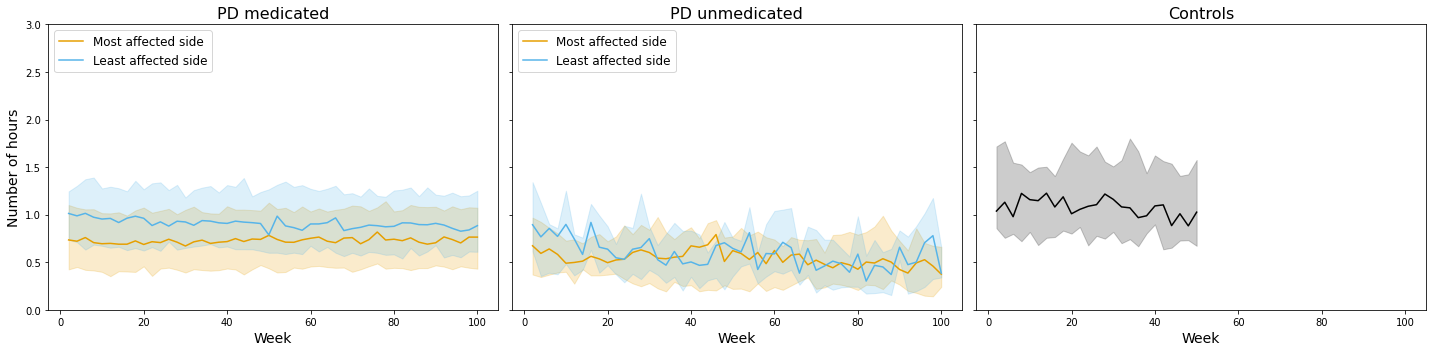

In [19]:
static_or_dynamic = 'static'
filter_type = 'filtered'
segment_length = '0_20'

fig, ax = plt.subplots(ncols=3, figsize=(20, 5), sharex=True, sharey=True)

print(f"Number of participants per group at baseline:")
print(f"\n{filter_type} gait")
for j, group in enumerate(['pd_med', 'pd_no_med', 'controls']):
    if 'pd' in group:
        weeks = weeks_2y
        population = 'pd'
        med_state = group.split('pd_')[1]
    else:
        weeks = weeks_1y
        population = 'controls'

    df_lng_group = digital_measures.loc[
        (digital_measures['population']==population) & 
        (digital_measures['segment_category'] == segment_length) &
        (digital_measures['filter_type'] == filter_type)
    ]

    iqr_list = []
    for week in weeks:
        if population == 'pd':
            for aff_side in ['mas', 'las']:
                if static_or_dynamic == 'static':
                    valid_ids = srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][str(final_week_2y)]
                else:
                    valid_ids = srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][str(week)]
                df_week = df_lng_group.loc[
                    (df_lng_group['week'] == week) &
                    (df_lng_group['affected_side'] == aff_side) &
                    (df_lng_group['id'].isin(valid_ids)) &
                    (df_lng_group['sufficient_arm_swing_this_week'])
                ]

                iqr_list.append([
                    week,
                    aff_side,
                    np.percentile(df_week['duration_s'] / 3600, 25), 
                    np.percentile(df_week['duration_s'] / 3600, 50), 
                    np.percentile(df_week['duration_s'] / 3600, 75)
                ])   

                if week == start_week and aff_side == 'mas':
                    N_mas = df_week['id'].nunique()
                elif week == start_week:
                    N_las = df_week['id'].nunique()
        else:
            if static_or_dynamic == 'static':
                valid_ids = srm_ids_per_week[segment_length][population][str(final_week_1y)]
            else:
                valid_ids = srm_ids_per_week[segment_length][population][str(week)]
            df_week = df_lng_group.loc[
                (df_lng_group['week'] == week) & 
                (df_lng_group['id'].isin(valid_ids)) &
                (df_lng_group['sufficient_arm_swing_this_week'])
            ]

            iqr_list.append([
                week,
                aff_side,
                np.percentile(df_week['duration_s'] / 3600, 25), 
                np.percentile(df_week['duration_s'] / 3600, 50), 
                np.percentile(df_week['duration_s'] / 3600, 75)
            ])   
        
            if week == start_week:
                N = df_week['id'].nunique()

    df_iqr = pd.DataFrame(iqr_list)
    df_iqr.columns = ['week', 'aff_side', '25p', '50p', '75p']

    if population == 'pd':
        for aff_side, color in zip(['mas', 'las'], [COLOR_GROUP_1, COLOR_GROUP_2]):
            df_aff = df_iqr.loc[df_iqr['aff_side']==aff_side]
            sns.lineplot(df_aff, x='week', y='50p', ax=ax[j], label=f'{AFFECTED_SIDE_RENAMING[aff_side]}', color=color)
            ax[j].fill_between(df_aff['week'], df_aff['25p'], df_aff['75p'], alpha=0.2, color=color)

        ax[j].legend(loc='upper left', fontsize=12)
    else:
        sns.lineplot(df_iqr, x='week', y='50p', ax=ax[j], label='', color='black')
        ax[j].fill_between(df_iqr['week'], df_iqr['25p'], df_iqr['75p'], alpha=0.2, color='black')

    ax[j].set_ylim([0, 3])

    ax[j].set_title(f'{GROUP_RENAMING[group]}', size=16)
    ax[j].set_ylabel('Number of hours', size=14)
    ax[j].set_xlabel('Week', size=14)
    

    if population == 'pd':
        print(f"- {GROUP_RENAMING[group]}: {N_mas} MAS, {N_las} LAS")
    else:
        print(f"- {GROUP_RENAMING[group]}: {N}")

plt.tight_layout()
plt.show()

Number of participants per group at baseline:

filtered gait
Mean +/- SD amount of filtered gait segments in pd_med
- Abs - 20_inf: 2.1 +/- 1.7 hours
- PD medicated: 301
Mean +/- SD amount of filtered gait segments in pd_no_med
- Abs - 20_inf: 2.7 +/- 2.7 hours
- PD unmedicated: 19
Mean +/- SD amount of filtered gait segments in controls
- Abs - 20_inf: 1.8 +/- 1.1 hours
- Controls: 28


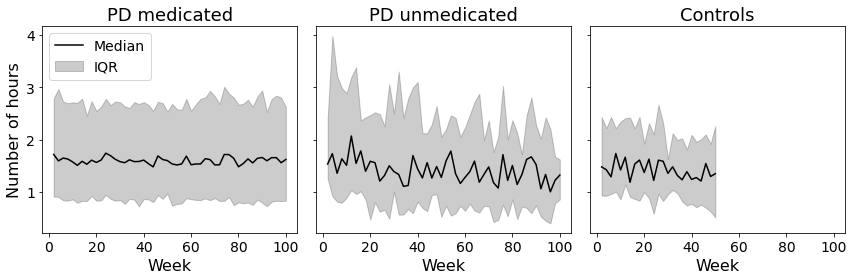

In [20]:
static_or_dynamic = 'static'
filter_type = 'filtered'
segment_length = '20_inf'

fig, ax = plt.subplots(ncols=3, figsize=(12, 4), sharex=True, sharey=True)

print(f"Number of participants per group at baseline:")
print(f"\n{filter_type} gait")

rounding_decimals = 1

for j, group in enumerate(['pd_med', 'pd_no_med', 'controls']):
    if 'pd' in group:
        weeks = weeks_2y
        population = 'pd'
        med_state = group.split('pd_')[1]
    else:
        weeks = weeks_1y
        population = 'controls'

    df_lng_group = digital_measures.loc[
        (digital_measures['population']==population) & 
        (digital_measures['segment_category'] == segment_length) &
        (digital_measures['filter_type'] == filter_type)
    ]

    iqr_list = []
    for week in weeks:
        if population == 'pd':
            if static_or_dynamic == 'static':
                valid_ids = srm_ids_per_week[segment_length][f'{population}_mas_{med_state}'][str(final_week_2y)] + srm_ids_per_week[segment_length][f'{population}_las_{med_state}'][str(final_week_2y)]
            else:
                valid_ids = srm_ids_per_week[segment_length][f'{population}_mas_{med_state}'][str(week)] + srm_ids_per_week[segment_length][f'{population}_las_{med_state}'][str(week)]
                
            df_week = df_lng_group.loc[
                (df_lng_group['week'] == week) &
                (df_lng_group['id'].isin(valid_ids)) &
                (df_lng_group['sufficient_arm_swing_this_week'])
            ]

            iqr_list.append([
                week,
                np.percentile(df_week['duration_s'] / 3600, 25), 
                np.percentile(df_week['duration_s'] / 3600, 50), 
                np.percentile(df_week['duration_s'] / 3600, 75)
            ])   

            if week == start_week:
                N = df_week['id'].nunique()
        else:
            if static_or_dynamic == 'static':
                valid_ids = srm_ids_per_week[segment_length][population][str(final_week_1y)]
            else:
                valid_ids = srm_ids_per_week[segment_length][population][str(week)]
            df_week = df_lng_group.loc[
                (df_lng_group['week'] == week) & 
                (df_lng_group['id'].isin(valid_ids)) &
                (df_lng_group['sufficient_arm_swing_this_week'])
            ]

            iqr_list.append([
                week,
                np.percentile(df_week['duration_s'] / 3600, 25), 
                np.percentile(df_week['duration_s'] / 3600, 50), 
                np.percentile(df_week['duration_s'] / 3600, 75)
            ])   
        
            if week == start_week:
                N = df_week['id'].nunique()

        if week == start_week:
            print(f"Mean +/- SD amount of {filter_type} gait segments in {group}")
            start_week_hrs = df_week['duration_s'].values / 3600
            print(f"- Abs - {segment_length}: {np.round(np.nanmean(start_week_hrs), rounding_decimals)} +/- {np.round(np.nanstd(start_week_hrs), rounding_decimals)} hours")
        elif week == final_week_2y and 'pd' in group or week == final_week_1y and group == 'controls':
            final_week_hrs = df_week['duration_s'].values / 3600
            # delta_hrs = final_week_hrs - start_week_hrs
            # div_factor = 2 if 'pd' in group else 1
            # pct_change = delta_hrs / div_factor
            # print(f"- Delta - {segment_length}: {np.round(np.nanmean(pct_change), rounding_decimals)} +/- {np.round(np.nanstd(pct_change), rounding_decimals)} hours")

    df_iqr = pd.DataFrame(iqr_list)
    df_iqr.columns = ['week', '25p', '50p', '75p']

    sns.lineplot(df_iqr, x='week', y='50p', ax=ax[j], color='black', label='Median')
    ax[j].fill_between(df_iqr['week'], df_iqr['25p'], df_iqr['75p'], alpha=0.2, color='black', label='IQR')

    # ax[j].set_ylim([2, 10.2])

    if population == 'pd':
        ax[j].set_title(GROUP_RENAMING[group], size=PLOT_TITLESIZE)
    else:
        ax[j].set_title(GROUP_RENAMING[group], size=PLOT_TITLESIZE)

    ax[j].set_ylabel('Number of hours', size=PLOT_LABELSIZE)
    ax[j].set_xlabel('Week', size=PLOT_LABELSIZE)
    ax[j].get_legend().remove()
    ax[j].tick_params(labelsize=PLOT_TICKSIZE)

    print(f"- {GROUP_RENAMING[group]}: {N}")

ax[0].legend(loc='upper left', fontsize=PLOT_LEGEND_FONTSIZE)

plt.tight_layout()
plt.show()

if save_plots:
    fig.savefig(os.path.join(PATH_FIGURES, f"r_lng_quant_as_{segment_length}.png"), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', f"r_lng_quant_as_{segment_length}.pdf"), dpi=600, bbox_inches='tight')

In [21]:
segment_length = '0_20'
filter_type = 'filtered'
required_weeks = {
    'pd_med': [start_week, final_week_1y, final_week_2y],
    'pd_no_med': [start_week, final_week_1y, final_week_2y],
    'controls': [start_week, final_week_1y]
}

valid_ids_per_week = {
    'pd_med': {},
    'pd_no_med': {},
    'controls': {}
}

hrs = {}
for group in required_weeks:
    hrs[group] = {}
    for week in required_weeks[group]:
        if 'no_med' in group:
            valid_ids_per_week[group][week] = srm_ids_per_week[segment_length][f'{group.split('_')[0]}_mas_{group.split('_')[1]}_{group.split('_')[2]}'][str(week)] + \
                srm_ids_per_week[segment_length][f'{group.split('_')[0]}_las_{group.split('_')[1]}_{group.split('_')[2]}'][str(week)]
        elif 'med' in group:
            valid_ids_per_week[group][week] = srm_ids_per_week[segment_length][f'{group.split('_')[0]}_mas_{group.split('_')[1]}'][str(week)] + \
                srm_ids_per_week[segment_length][f'{group.split('_')[0]}_las_{group.split('_')[1]}'][str(week)]
        else:
            valid_ids_per_week[group][week] = srm_ids_per_week[segment_length][group][str(week)]

    valid_ids = [x for x in valid_ids_per_week[group][start_week] if all(x in valid_ids_per_week[group][week] for week in required_weeks[group])]

    for week in required_weeks[group]:
        hrs[group][week] = digital_measures.loc[
            (digital_measures['week'] == week) & 
            (digital_measures['filter_type'] == filter_type) &
            (digital_measures['segment_category'] == segment_length) &
            (digital_measures['id'].isin(valid_ids)),
            'duration_s'
        ].values / 3600

### Arm swing parameters longitudinally

In [29]:
signal_values

,week2,week4,week6,week8,week10,week12,week14,week16,week18,week20,...,week86,week88,week90,week92,week94,week96,week98,week100,week102,week104
0,22.834077,21.000261,19.166445,17.332630,15.498814,13.664998,13.152640,12.640283,12.127927,11.615570,...,15.262063,15.944683,16.627307,17.309939,17.992570,18.675203,19.357835,20.040467,20.723099,21.405731
1,26.790340,27.579415,28.368490,29.157565,29.946638,29.852318,29.757998,29.663677,29.569357,29.475036,...,29.631366,29.350340,29.069314,28.788288,28.507262,NaN,NaN,NaN,NaN,NaN
2,22.934312,23.266917,23.599521,23.932125,24.264730,24.597337,24.929944,25.262551,25.595158,25.927764,...,13.706380,13.375345,13.044310,12.713275,12.382241,12.051207,11.720173,11.389139,11.058104,10.727070
3,30.668272,31.357614,32.046955,32.736297,35.412222,38.088147,40.764072,43.439997,44.271076,45.102156,...,40.486009,40.256214,40.026418,39.796622,39.566826,39.337030,39.107234,38.877438,38.647641,38.417844
4,11.095433,11.082955,11.070477,11.057999,11.045521,11.033044,11.020566,11.008088,10.995611,10.983134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506,24.501128,28.368994,32.236860,36.104725,39.972592,43.840457,43.033206,42.225955,41.418704,40.611453,...,33.927757,34.413928,34.900098,36.796366,38.692635,40.588904,42.485172,44.381441,46.277709,NaN
507,14.544753,14.230340,13.915928,13.601516,13.287104,12.972692,12.658279,12.343867,12.029456,11.715044,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
508,12.403459,12.644433,12.885406,13.126379,13.367352,13.608325,13.849298,14.090270,14.331243,14.572216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
509,11.070088,11.785228,12.500367,13.215507,13.930647,14.645788,15.360928,16.076070,16.791211,17.506353,...,9.126924,9.102371,9.077818,9.053266,9.028712,9.004159,8.979606,8.955052,8.930499,8.905945


- PD medicated: 187 MAS, 114 LAS
- PD unmedicated: 17 MAS, 5 LAS
- Controls: 29
- PD medicated: 187 MAS, 114 LAS
- PD unmedicated: 17 MAS, 5 LAS
- Controls: 29
- PD medicated: 187 MAS, 114 LAS
- PD unmedicated: 17 MAS, 5 LAS
- Controls: 29


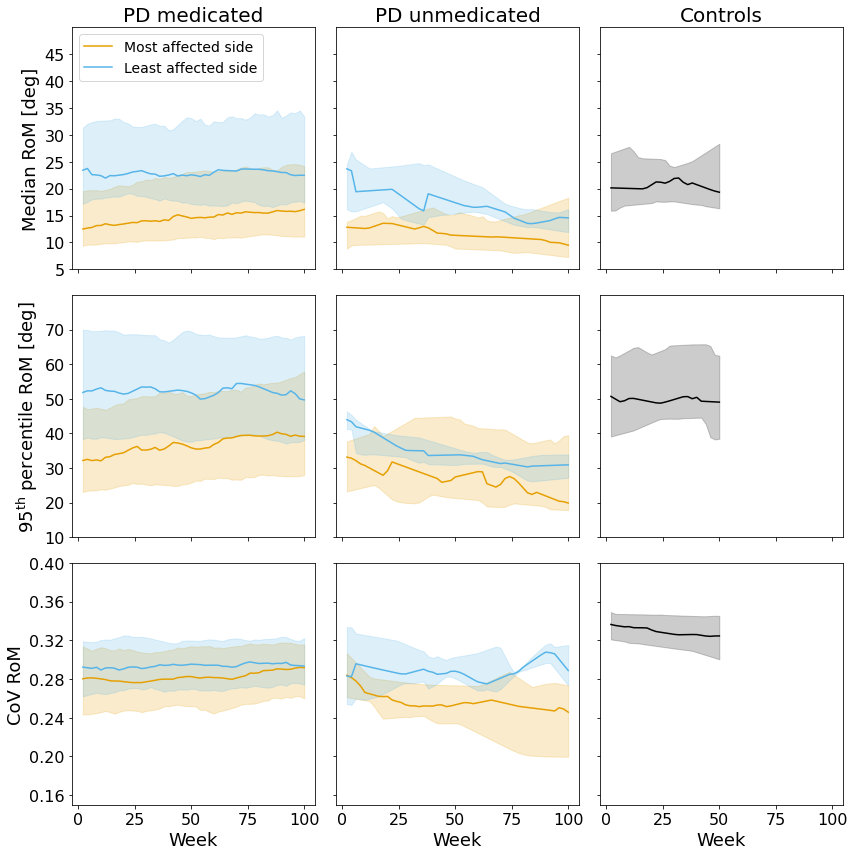

In [39]:
filter_type = 'filtered'
static_or_dynamic = 'static'
segment_length = '20_inf'

interpolated = True
plot_controls = True

measures = ['median', '95p', 'median_cov']

if plot_controls:
    ncols = 3
    groups = ['pd_med', 'pd_no_med', 'controls']
else:
    ncols = 2
    groups = ['pd_med', 'pd_no_med']

fig, ax = plt.subplots(nrows=len(measures), ncols=ncols, figsize=(ncols * 4, 12), sharex=True, sharey=False)

for i, measure in enumerate(measures):
    for j, group in enumerate(groups):
        if 'pd' in group:
            weeks = weeks_2y
            population = 'pd'
            med_state = group.split('pd_')[1]
        else:
            weeks = weeks_1y
            population = 'controls'

        path_to_measures = os.path.join(BASE_PATH, 'measures', f'{filter_type}_gait', segment_length)

        if interpolated:
            signal_values = pd.read_csv(os.path.join(path_to_measures, f'{population}_signal_interp_{measure}_range_of_motion.csv'))   
        else:
            signal_values = pd.read_csv(os.path.join(path_to_measures, f'{population}_signal_{measure}_range_of_motion.csv'))   

        if signal_values.shape[0] == 511:
            signal_values = signal_values.drop(509).reset_index(drop=True)

        iqr_list = []
        for week in weeks:
            week_measures = signal_values[f'week{week}']
            if population == 'pd':
                for aff_side in ['mas', 'las']:
                    if static_or_dynamic == 'static':
                        valid_ids = srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][f'{final_week_2y}']
                    else:
                        valid_ids = srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][str(week)]
                        
                    filtered_measures = [week_measures[idx] for idx in week_measures.index if pd_ids[idx] in valid_ids and pd.notna(week_measures[idx])]

                    iqr_list.append([
                        week,
                        aff_side,
                        np.nanpercentile(filtered_measures, 25), 
                        np.nanpercentile(filtered_measures, 50), 
                        np.nanpercentile(filtered_measures, 75)
                    ])   

                    if week == start_week and aff_side == 'mas':
                        N_mas = len(filtered_measures)
                    elif week == start_week:
                        N_las = len(filtered_measures)

            else:
                if static_or_dynamic == 'static':
                    valid_ids = srm_ids_per_week[segment_length][population][f'{final_week_1y}']
                else:
                    valid_ids = srm_ids_per_week[segment_length][population][str(week)]
                filtered_measures = [week_measures[idx] for idx in week_measures.index if controls_ids[idx] in valid_ids]

                iqr_list.append([
                    week,
                    aff_side,
                    np.nanpercentile(filtered_measures, 25), 
                    np.nanpercentile(filtered_measures, 50), 
                    np.nanpercentile(filtered_measures, 75)
                ])   
            
                if week == start_week:
                    N = len(filtered_measures)

        df_iqr = pd.DataFrame(iqr_list)
        df_iqr.columns = ['week', 'aff_side', '25p', '50p', '75p']

        if population == 'pd':
            for aff_side, color in zip(['mas', 'las'], [COLOR_GROUP_1, COLOR_GROUP_2]):
                df_aff = df_iqr.loc[df_iqr['aff_side']==aff_side]
                sns.lineplot(df_aff, x='week', y='50p', ax=ax[i,j], color=color, label=f'{AFFECTED_SIDE_RENAMING[aff_side]}')
                ax[i,j].fill_between(df_aff['week'], df_aff['25p'], df_aff['75p'], alpha=0.2, color=color)#, label=f'IQR ({AFFECTED_SIDE_RENAMING[aff_side]})')

        else:
            sns.lineplot(df_iqr, x='week', y='50p', ax=ax[i,j], color='black')#, label='Median')
            ax[i,j].fill_between(df_iqr['week'], df_iqr['25p'], df_iqr['75p'], alpha=0.2, color='black')#, label='IQR')

        if j != 2:
            ax[i,j].get_legend().remove()

        if i == 0:
            ax[i,j].set_title(GROUP_RENAMING[group], size=20)

        ax[i,j].set_xlabel('Week', size=18)

        if i == 2:
            ax[i,j].set_ylabel(f'{AGGREGATION_RENAMING[measure]} RoM', size=18)
        else:
            ax[i,j].set_ylabel(f'{AGGREGATION_RENAMING[measure]} RoM [deg]', size=18)

        ax[i,j].tick_params(labelsize=16)
        ax[i,j].yaxis.set_major_locator(MaxNLocator(nbins=7))

        if population == 'pd':
            print(f"- {GROUP_RENAMING[group]}: {N_mas} MAS, {N_las} LAS")
        else:
            print(f"- {GROUP_RENAMING[group]}: {N}")

ax[0, 0].legend(loc='upper left', fontsize=14)

for i in range(len(measures)):
    for j in range(1, 3):
        ax[i, j].sharey(ax[i, 0])
        ax[i, j].set_ylabel('')
        ax[i, j].tick_params(labelleft=False)
    
for i in range(len(measures)): 
    ymins = [ax[i, j].get_ylim()[0] for j in range(ncols)]
    ymaxs = [ax[i, j].get_ylim()[1] for j in range(ncols)]

    if i == 0:
        ymin = 5 
        ymaxs = [ymax + 5 for ymax in ymaxs]
        reps = 5
    elif i == 1:
        ymin = 10
        reps = 10
    else:
        ymin = 0
        reps = 5

    ymax = int(np.ceil(max(ymaxs) / 10) * 10)  # round up to nearest 10
    yticks = np.arange(ymin, ymax, reps)

    for j in range(ncols):
        if i != 2:
            ax[i, j].set_ylim([ymin, ymax])
            ax[i, j].set_yticks(yticks)
            ax[i, j].set_yticklabels(yticks)
        else:
            ax[i, j].set_ylim([0.15, 0.4])

plt.tight_layout()
plt.show()

- PD medicated: 184 MAS, 113 LAS
- PD unmedicated: 18 MAS, 5 LAS
- Controls: 29
- PD medicated: 184 MAS, 113 LAS
- PD unmedicated: 18 MAS, 5 LAS
- Controls: 29


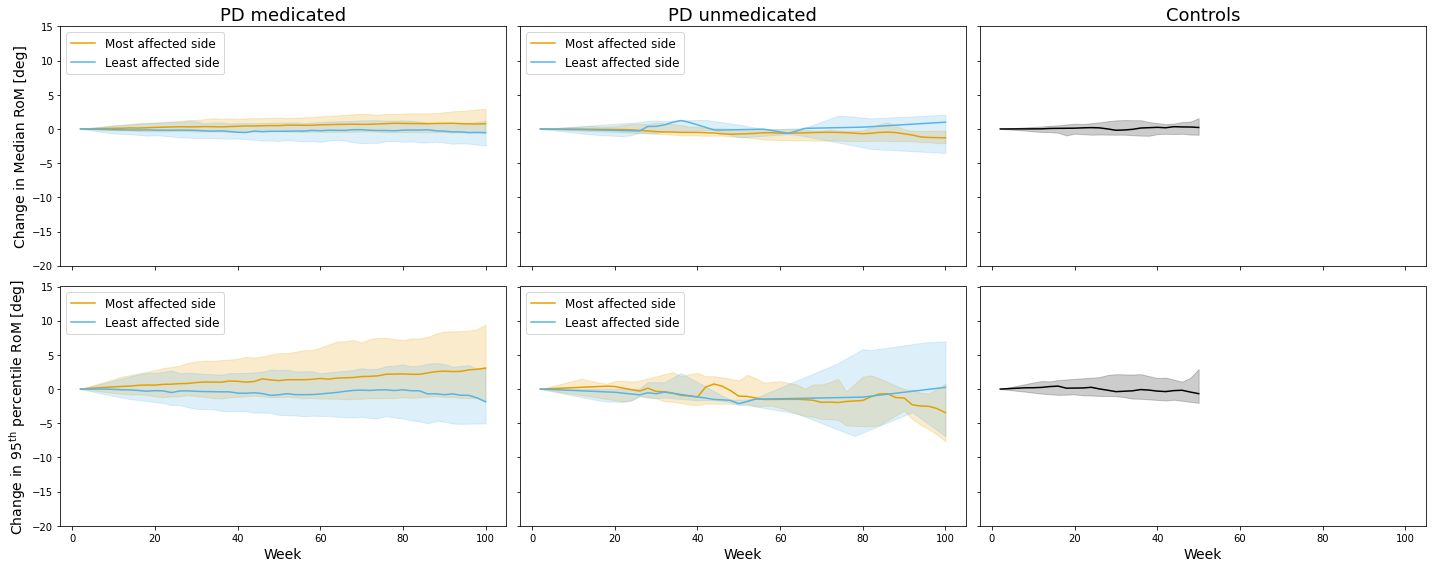

In [ ]:
filter_type = 'filtered'
static_or_dynamic = 'static'
segment_length = 'not_very_long'
start_week = 2

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(20, 8), sharex=True, sharey=True)

for i, measure in enumerate(['median', '95p']):
    for j, group in enumerate(['pd_med', 'pd_no_med', 'controls']):
        if 'pd' in group:
            weeks = weeks_2y
            population = 'pd'
            med_state = group.split('pd_')[1]
        else:
            weeks = weeks_1y
            population = 'controls'

        path_to_measures = os.path.join(BASE_PATH, 'measures', f'{filter_type}_gait', f'{segment_length}_gait_segments')
        interpolated_measures = pd.read_csv(os.path.join(path_to_measures, f'{population}_signal_interp_{measure}.csv'))

        start_week_measures = interpolated_measures[f'week{start_week}']

        iqr_list = []
        for week in weeks:
            week_measures = interpolated_measures[f'week{week}']
            if population == 'pd':
                for aff_side in ['mas', 'las']:
                    start_week_ids = srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][str(start_week)]
                    if static_or_dynamic == 'static':
                        valid_ids = [id for id in srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][f'{final_week_2y}'] if id in start_week_ids]
                    else:
                        valid_ids = [id for id in srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][str(week)] if id in start_week_ids]
                        
                    filtered_measures = [week_measures[idx] - start_week_measures[idx] for idx in week_measures.index if pd_ids[idx] in valid_ids and pd.notna(week_measures[idx])]

                    iqr_list.append([
                        week,
                        aff_side,
                        np.nanpercentile(filtered_measures, 25), 
                        np.nanpercentile(filtered_measures, 50), 
                        np.nanpercentile(filtered_measures, 75)
                    ])   

                    if week == start_week and aff_side == 'mas':
                        N_mas = len(filtered_measures)
                    elif week == start_week:
                        N_las = len(filtered_measures)
            else:
                start_week_ids = srm_ids_per_week[segment_length][population][str(start_week)]
                if static_or_dynamic == 'static':
                    valid_ids = [id for id in srm_ids_per_week[segment_length][population][f'{final_week_1y}'] if id in start_week_ids]
                else:
                    valid_ids = [id for id in srm_ids_per_week[segment_length][population][str(week)] if id in start_week_ids]

                filtered_measures = [week_measures[idx] - start_week_measures[idx] for idx in week_measures.index if controls_ids[idx] in valid_ids]

                iqr_list.append([
                    week,
                    aff_side,
                    np.nanpercentile(filtered_measures, 25), 
                    np.nanpercentile(filtered_measures, 50), 
                    np.nanpercentile(filtered_measures, 75)
                ])   
            
                if week == start_week:
                    N = len(filtered_measures)

        df_iqr = pd.DataFrame(iqr_list)
        df_iqr.columns = ['week', 'aff_side', '25p', '50p', '75p']

        if population == 'pd':
            for aff_side, color in zip(['mas', 'las'], [COLOR_GROUP_1, COLOR_GROUP_2]):
                df_aff = df_iqr.loc[df_iqr['aff_side']==aff_side]
                sns.lineplot(df_aff, x='week', y='50p', ax=ax[i,j], label=AFFECTED_SIDE_RENAMING[aff_side], color=color)
                ax[i,j].fill_between(df_aff['week'], df_aff['25p'], df_aff['75p'], alpha=0.2, color=color)
        else:
            sns.lineplot(df_iqr, x='week', y='50p', ax=ax[i,j], label='Controls', color='black')
            ax[i,j].fill_between(df_iqr['week'], df_iqr['25p'], df_iqr['75p'], alpha=0.2, color='black')

        ax[1,j].set_ylim([-20, 15])

        ax[i,j].set_ylabel(f'Change in {DIGITAL_MEASURE_RENAMING[measure]} RoM [deg]', size=14)
        ax[i,j].set_xlabel('Week', size=14)
        ax[i,j].legend(loc='upper left', fontsize=12)

        if population == 'pd':
            print(f"- {GROUP_RENAMING[group]}: {N_mas} MAS, {N_las} LAS")
        else:
            print(f"- {GROUP_RENAMING[group]}: {N}")

ax[0, 0].set_title('PD medicated', size=PLOT_TITLESIZE)
ax[0, 1].set_title('PD unmedicated', size=PLOT_TITLESIZE)
ax[0, 2].set_title('Controls', size=PLOT_TITLESIZE)

for i in range(2):
    ax[i, 2].legend().remove()

plt.tight_layout()
plt.show()